# Day 1 — From Machine Learning to Deep Learning

## Note 1.3 — Your First PyTorch Network

## Learning Goal & Outcome

**Goal.** Express the mechanism you traced by hand in Note 1.2 as idiomatic PyTorch, and train a working model with it.

**Outcome.** You can build a neural network, write its training loop unaided, justify every line of that loop, evaluate it honestly on held-out data, save it, reload it — and diagnose it when it silently stops learning.

## Objectives

By the end of this note you will be able to:

- create and inspect tensors, and explain shape, dtype and device;
- detect the available accelerator and write code that runs on CPU, MPS or CUDA unchanged;
- convert NumPy arrays into tensors correctly, including the dtype trap that catches everyone once;
- define a model both as raw tensors and as an `nn.Module`, and say why the second is preferred;
- choose an appropriate loss function and explain the logits-versus-probabilities distinction;
- explain what `optimizer.step()` and `optimizer.zero_grad()` do in terms of Note 1.2;
- write a complete training loop with a validation split;
- read a training curve and say what it implies;
- save and reload model weights the way practitioners actually do it;
- recognise three common causes of silent training failure from their symptoms alone.

## Dataset Used

| Dataset | Modality | Role in this note | Source |
|---|---|---|---|
| **Two Spirals** | Synthetic 2-D | The same problem that defeated logistic regression in Note 1.1 | Generated in-notebook, no download |

We return deliberately to the spirals. In Note 1.1 a black-box `MLPClassifier` solved them and you had no idea how. You now know exactly how. This note closes that loop by building the solver yourself.

There is no `DataLoader` here and no batching — the full dataset is one tensor of 1,000 rows. Datasets, DataLoaders and mini-batching are Day 2's material, and introducing them today would obscure the loop rather than clarify it.

**Runtime.** Every cell runs in seconds on CPU. No GPU required.

## Table of Contents

1. [Tensors: shape, dtype, device](#s1)
2. [Environment detection — CUDA, MPS, CPU](#s2)
3. [Tensor operations that matter for networks](#s3)
4. [From NumPy to tensors](#s4)
5. [The model, twice: raw tensors, then nn.Module](#s5)
6. [Loss functions in PyTorch](#s6)
7. [Optimizers: what .step() replaces](#s7)
8. [The training loop, line by line](#s8)
9. [Training on the spirals](#s9)
10. [Reading the loss curve](#s10)
11. [Prediction](#s11)
12. [Saving and loading weights](#s12)
13. [Deliberate breakage: three changes that stop learning](#s13)
14. [End-of-day competency check](#s14)
15. [Conclusion](#s15)

## Setup

In [1]:
# torch>=2.4  numpy>=2.0  matplotlib>=3.8
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

print("torch", torch.__version__)
print("numpy", np.__version__)

torch 2.14.0
numpy 2.3.5


## 1. Tensors: shape, dtype, device

A tensor is an array of numbers with three properties that you will check constantly:

- **shape** — its dimensions;
- **dtype** — the numeric type of its elements;
- **device** — the physical hardware holding it.

If you know NumPy, the first two are familiar. The third is new, and it is the one that will throw errors at you.

The word "tensor" sounds mathematical, but in practice it means an array with a rank:

| Rank | Name | Example in deep learning |
|---|---|---|
| 0 | scalar | a loss value |
| 1 | vector | one embedding |
| 2 | matrix | a batch of tabular rows, `(batch, features)` |
| 3 | 3-tensor | a batch of token sequences, `(batch, tokens, features)` |
| 4 | 4-tensor | a batch of images, `(batch, channels, height, width)` |

Almost every shape error you will ever hit comes from confusing two of these, or from losing track of which axis is the batch.

> **🖼️ IMAGE 1.3.1 — Tensor ranks**

<div align="center">

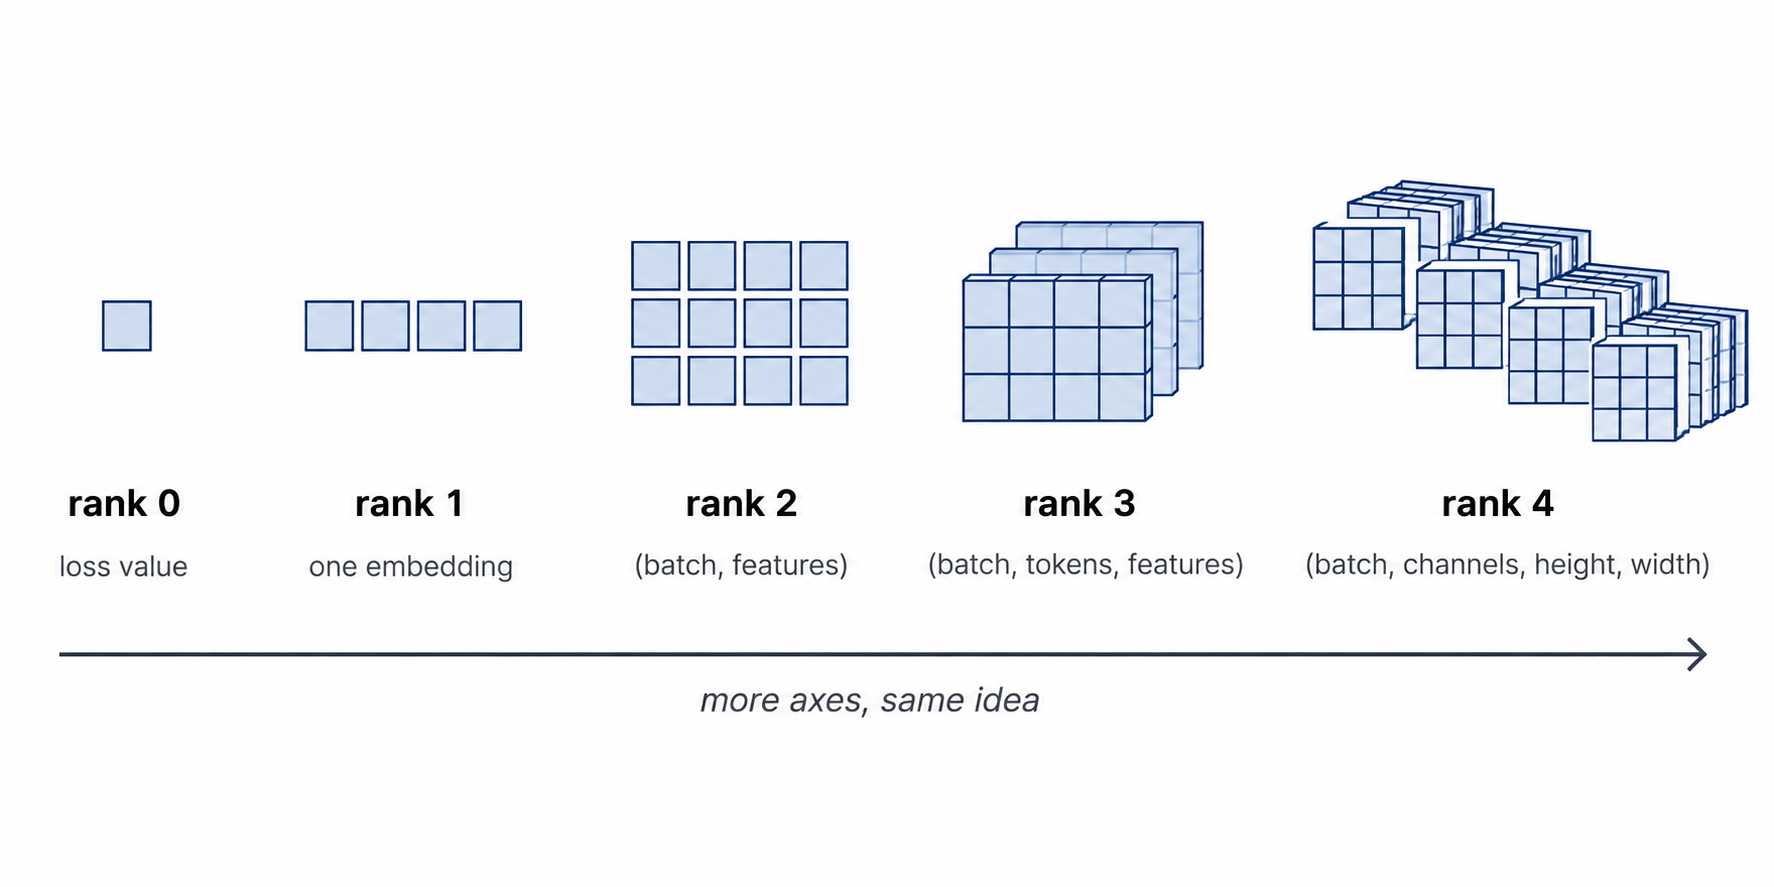


</div>

In [2]:
scalar = torch.tensor(3.14)
vector = torch.tensor([1.0, 2.0, 3.0])
matrix = torch.tensor([[1.0, 2.0], [3.0, 4.0], [5.0, 6.0]])
batch_of_images = torch.zeros(8, 3, 32, 32)   # 8 images, 3 colour channels, 32x32 pixels

for name, t in [("scalar", scalar), ("vector", vector),
                ("matrix", matrix), ("image batch", batch_of_images)]:
    print(f"{name:<14} shape={str(tuple(t.shape)):<20} rank={t.dim()}  dtype={t.dtype}  device={t.device}")

scalar         shape=()                   rank=0  dtype=torch.float32  device=cpu
vector         shape=(3,)                 rank=1  dtype=torch.float32  device=cpu
matrix         shape=(3, 2)               rank=2  dtype=torch.float32  device=cpu
image batch    shape=(8, 3, 32, 32)       rank=4  dtype=torch.float32  device=cpu


Two dtype facts worth internalising now, because both will cost you time otherwise.

**Deep learning runs on `float32`, not `float64`.** NumPy defaults to `float64`; PyTorch defaults to `float32`. That is deliberate — half the memory, and much faster on GPUs, at precision that neural networks simply do not need. On Day 4 you will go further down to `float16` and `bfloat16` for mixed-precision training.

**Integer labels stay integers.** Class labels for multi-class problems must be `int64` (PyTorch calls it `long`). Passing floats where a loss function expects longs produces an error message that is not especially helpful the first time you meet it.

In [3]:
a = torch.tensor([1.0, 2.0])            # float32 by default
b = torch.tensor([1, 2])                # int64 by default
c = torch.tensor(np.array([1.0, 2.0]))  # inherits float64 from NumPy  <-- the trap

print(f"from python floats : {a.dtype}")
print(f"from python ints   : {b.dtype}")
print(f"from a numpy array : {c.dtype}   <-- not float32!")

# Two ways to fix it
print(f"\nfixed with .float()   : {c.float().dtype}")
print(f"fixed at creation     : {torch.tensor(np.array([1.0, 2.0]), dtype=torch.float32).dtype}")

from python floats : torch.float32
from python ints   : torch.int64
from a numpy array : torch.float64   <-- not float32!

fixed with .float()   : torch.float32
fixed at creation     : torch.float32


**Questions.**

1. A batch of 16 RGB images at 64×64 pixels — what is its shape as a tensor?
2. Why would `float64` be wasteful on a GPU?
3. You have a `(1000, 2)` tensor of features. What does `t[0]` return, and what shape is it?

## 2. Environment detection — CUDA, MPS, CPU

A tensor lives somewhere specific: in system RAM, or in the memory of an accelerator. Operations require all their inputs on the **same** device, and the error you get when they are not is one you will see many times.

Three backends matter in 2026:

- **`cuda`** — NVIDIA GPUs. What free Colab and Kaggle give you, and what almost all production inference runs on.
- **`mps`** — Apple Silicon, via Metal Performance Shaders. Fast for a laptop, and fine for most of this course. Be aware that CUDA-only libraries such as `bitsandbytes`, `vLLM` and `flash-attn` will not run on it — that is why Days 8 and 9 route those specific labs to Colab or Kaggle.
- **`cpu`** — always available, slower for large models, entirely adequate for everything in Day 1.

Write the detection once, at the top of every notebook, and never hard-code a device again.

In [4]:
def get_device():
    """Pick the best available accelerator. Works unchanged on Colab, Kaggle, Mac or CPU."""
    if torch.cuda.is_available():
        return torch.device("cuda")
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")


DEVICE = get_device()
print(f"Using device: {DEVICE}")

Using device: mps


In [5]:
if DEVICE.type == "cuda":
    print(f"  GPU:  {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
elif DEVICE.type == "mps":
    print("  Apple Silicon GPU via Metal.")
    print("  Note: bitsandbytes, vLLM and flash-attn are CUDA-only — use Colab/Kaggle for those labs.")
else:
    print("  CPU only. Everything in Day 1 runs comfortably here.")

  Apple Silicon GPU via Metal.
  Note: bitsandbytes, vLLM and flash-attn are CUDA-only — use Colab/Kaggle for those labs.


In [6]:
# Moving a tensor between devices
x = torch.randn(3, 2)
print(f"created on: {x.device}")

created on: cpu


In [7]:
x = x.to(DEVICE)
print(f"moved to:   {x.device}")

moved to:   mps:0


In [8]:
# The classic error, demonstrated safely
if DEVICE.type != "cpu":
    y_cpu = torch.randn(3, 2)
    try:
        _ = x + y_cpu
    except RuntimeError as e:
        print(f"\nDevice mismatch error:\n  {str(e)[:130]}")
    print("\nFix: put both on the same device with .to(DEVICE)")
else:
    print("\n(Device-mismatch demo skipped — only one device available.)")


Device mismatch error:
  Expected all tensors to be on the same device, but found at least two devices, mps:0 and cpu!

Fix: put both on the same device with .to(DEVICE)


**Questions.**

1. Why does `.to(DEVICE)` return a tensor rather than modifying in place? What does that imply about `x.to(DEVICE)` written on a line by itself?
2. Model parameters *and* input data must be on the same device. Which of the two is easier to forget?
3. Day 1 runs fine on CPU. What property of these models makes that true, and when will it stop being true?

## 3. Tensor operations that matter for networks

You do not need the full tensor API. You need the handful of operations that appear inside every forward pass, and a working instinct for shapes.

In [9]:
A = torch.tensor([[1.0, 2.0],
                  [3.0, 4.0],
                  [5.0, 6.0]])          # (3, 2)  — think: 3 examples, 2 features
A

tensor([[1., 2.],
        [3., 4.],
        [5., 6.]])

In [10]:
W = torch.tensor([[0.5, -0.5, 1.0],
                  [1.5,  0.0, 2.0]])    # (2, 3)  — think: 2 features in, 3 neurons out
W

tensor([[ 0.5000, -0.5000,  1.0000],
        [ 1.5000,  0.0000,  2.0000]])

In [11]:
A@W

tensor([[ 3.5000, -0.5000,  5.0000],
        [ 7.5000, -1.5000, 11.0000],
        [11.5000, -2.5000, 17.0000]])

In [12]:
print("A @ W  ->", tuple((A @ W).shape), "  (3,2) @ (2,3) -> (3,3)")
print("\nThe inner dimensions must match: (3,[2]) @ ([2],3). The outer ones survive.")

A @ W  -> (3, 3)   (3,2) @ (2,3) -> (3,3)

The inner dimensions must match: (3,[2]) @ ([2],3). The outer ones survive.


In [13]:
# Broadcasting: how a bias is added to every row at once
bias = torch.tensor([0.1, 0.2, 0.3])    # (3,)
print("\n(A @ W) + bias ->", tuple(((A @ W) + bias).shape), " — bias is reused for all 3 rows")


(A @ W) + bias -> (3, 3)  — bias is reused for all 3 rows


In [14]:
# Reshaping — the most common source of confusion
t = torch.arange(12.0)
t

tensor([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11.])

In [15]:
t.reshape(3, 4)

tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]])

In [16]:
t.reshape(3, -1)

tensor([[ 0.,  1.,  2.,  3.],
        [ 4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11.]])

In [17]:
t.reshape(12, 1)

tensor([[ 0.],
        [ 1.],
        [ 2.],
        [ 3.],
        [ 4.],
        [ 5.],
        [ 6.],
        [ 7.],
        [ 8.],
        [ 9.],
        [10.],
        [11.]])

In [18]:
t.unsqueeze(1)

tensor([[ 0.],
        [ 1.],
        [ 2.],
        [ 3.],
        [ 4.],
        [ 5.],
        [ 6.],
        [ 7.],
        [ 8.],
        [ 9.],
        [10.],
        [11.]])

In [19]:
print(f"\narange(12)          shape {tuple(t.shape)}")
print(f"reshape(3, 4)       shape {tuple(t.reshape(3, 4).shape)}")
print(f"reshape(3, -1)      shape {tuple(t.reshape(3, -1).shape)}   (-1 means 'infer this axis')")
print(f"unsqueeze(1) on (12,) -> {tuple(t.unsqueeze(1).shape)}   (adds an axis of size 1)")


arange(12)          shape (12,)
reshape(3, 4)       shape (3, 4)
reshape(3, -1)      shape (3, 4)   (-1 means 'infer this axis')
unsqueeze(1) on (12,) -> (12, 1)   (adds an axis of size 1)


`unsqueeze` deserves attention because it fixes a specific error you are about to meet. Labels naturally arrive with shape `(N,)`, but a network with one output neuron produces `(N, 1)`. Loss functions want these to match. `unsqueeze(1)` turns `(N,)` into `(N, 1)`.

Here is the habit that saves the most debugging time in this entire course: **print the shape whenever you are unsure.** Not once you have an error — before. Experienced practitioners scatter shape prints through new model code as a matter of routine and delete them afterwards.

In [20]:
def shapes(**tensors):
    """Print the shapes of several tensors at once. Use this liberally while developing."""
    for name, t in tensors.items():
        print(f"  {name:<12} {tuple(t.shape)}")

print("Inside a forward pass:")
h = A @ W
shapes(input=A, weights=W, hidden=h, bias=bias, output=h + bias)

Inside a forward pass:
  input        (3, 2)
  weights      (2, 3)
  hidden       (3, 3)
  bias         (3,)
  output       (3, 3)


**Questions.**

1. `(4, 3) @ (4, 3)` fails. Why, and what would you change to make it work?
2. What is the difference between a tensor of shape `(5,)` and one of shape `(5, 1)`? When does it matter?
3. Predict the result of broadcasting shape `(3, 1)` with shape `(1, 4)`. Then check.

## 4. From NumPy to tensors

Now we bring back the spirals. Same generator as Note 1.1, same parameters — and this time we split the data properly.

Note 1.2 trained on four examples and measured loss on those same four, which told us nothing about generalisation. That was acceptable for tracing arithmetic. It is not acceptable now. Every model from this point forward is judged on data it has not been trained on.

In [21]:
def make_spirals(n_per_class=500, noise=0.04, revolutions=2.5, seed=SEED):
    """Identical to Note 1.1 — two interleaved spiral arms, one per class."""
    rng = np.random.default_rng(seed)
    Xs, ys = [], []
    for c in range(2):
        t = np.sqrt(rng.random(n_per_class)) * revolutions * 2 * np.pi
        r = t / (revolutions * 2 * np.pi)
        theta = t + c * np.pi
        x1 = r * np.cos(theta) + rng.normal(0, noise, n_per_class)
        x2 = r * np.sin(theta) + rng.normal(0, noise, n_per_class)
        Xs.append(np.stack([x1, x2], axis=1))
        ys.append(np.full(n_per_class, float(c)))
    X = np.vstack(Xs)
    y = np.concatenate(ys)
    perm = rng.permutation(len(y))
    return X[perm], y[perm]

In [22]:
X_np, y_np = make_spirals()

In [23]:
X_np

array([[-0.55116798, -0.37382426],
       [ 0.1575606 ,  0.99847351],
       [-0.0345203 ,  0.07294894],
       ...,
       [-0.98668837,  0.02703767],
       [ 0.96692115, -0.14480294],
       [ 1.04025859, -0.2036717 ]], shape=(1000, 2))

In [24]:
y_np

array([0., 0., 0., 1., 0., 1., 1., 0., 1., 1., 1., 0., 0., 1., 0., 1., 1.,
       0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 0., 1., 1., 0., 0., 0.,
       1., 1., 1., 1., 0., 0., 0., 0., 1., 0., 1., 1., 0., 1., 1., 0., 1.,
       1., 1., 1., 0., 0., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
       0., 1., 1., 0., 0., 1., 0., 0., 0., 0., 1., 1., 0., 1., 0., 0., 1.,
       0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 1., 1., 0., 0., 0., 1., 0.,
       1., 1., 1., 1., 1., 1., 0., 1., 1., 0., 1., 0., 0., 0., 1., 1., 1.,
       1., 1., 1., 1., 0., 1., 0., 1., 0., 1., 1., 0., 0., 1., 0., 0., 0.,
       1., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 1., 0., 0.,
       1., 1., 1., 0., 0., 1., 0., 1., 0., 0., 1., 0., 1., 0., 0., 1., 1.,
       0., 0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 0., 1., 1., 1., 1.,
       1., 0., 1., 1., 1., 0., 1., 0., 0., 0., 0., 1., 1., 1., 0., 1., 1.,
       1., 0., 1., 1., 0., 0., 0., 0., 1., 1., 0., 1., 0., 1., 1., 0., 0.,
       1., 1., 1., 0., 0.

In [25]:
# 75/25 split. The data was already shuffled by the generator.
n_train = int(0.75 * len(y_np))
X_train_np, X_val_np = X_np[:n_train], X_np[n_train:]
y_train_np, y_val_np = y_np[:n_train], y_np[n_train:]

print(f"train: {X_train_np.shape[0]} examples   validation: {X_val_np.shape[0]} examples")
print(f"train class balance:      {np.bincount(y_train_np.astype(int))}")
print(f"validation class balance: {np.bincount(y_val_np.astype(int))}")

train: 750 examples   validation: 250 examples
train class balance:      [376 374]
validation class balance: [124 126]


In [26]:
X_train_np

array([[-0.55116798, -0.37382426],
       [ 0.1575606 ,  0.99847351],
       [-0.0345203 ,  0.07294894],
       ...,
       [-0.77171856, -0.36571913],
       [ 0.75867528, -0.56006283],
       [-0.26084541,  0.63325541]], shape=(750, 2))

In [27]:
DEVICE

device(type='mps')

In [28]:
# NumPy -> tensor, with dtype and device handled explicitly
X_train = torch.tensor(X_train_np, dtype=torch.float32, device=DEVICE)
X_val   = torch.tensor(X_val_np,   dtype=torch.float32, device=DEVICE)

In [29]:
X_train

tensor([[-0.5512, -0.3738],
        [ 0.1576,  0.9985],
        [-0.0345,  0.0729],
        ...,
        [-0.7717, -0.3657],
        [ 0.7587, -0.5601],
        [-0.2608,  0.6333]], device='mps:0')

In [30]:
# unsqueeze(1): (N,) -> (N, 1) so labels match the model's single-neuron output
y_train = torch.tensor(y_train_np, dtype=torch.float32, device=DEVICE).unsqueeze(1)
y_val   = torch.tensor(y_val_np,   dtype=torch.float32, device=DEVICE).unsqueeze(1)

In [31]:
y_train_np

array([0., 0., 0., 1., 0., 1., 1., 0., 1., 1., 1., 0., 0., 1., 0., 1., 1.,
       0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 0., 1., 1., 0., 0., 0.,
       1., 1., 1., 1., 0., 0., 0., 0., 1., 0., 1., 1., 0., 1., 1., 0., 1.,
       1., 1., 1., 0., 0., 1., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
       0., 1., 1., 0., 0., 1., 0., 0., 0., 0., 1., 1., 0., 1., 0., 0., 1.,
       0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 1., 1., 0., 0., 0., 1., 0.,
       1., 1., 1., 1., 1., 1., 0., 1., 1., 0., 1., 0., 0., 0., 1., 1., 1.,
       1., 1., 1., 1., 0., 1., 0., 1., 0., 1., 1., 0., 0., 1., 0., 0., 0.,
       1., 0., 1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 1., 0., 0.,
       1., 1., 1., 0., 0., 1., 0., 1., 0., 0., 1., 0., 1., 0., 0., 1., 1.,
       0., 0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 0., 1., 1., 1., 1.,
       1., 0., 1., 1., 1., 0., 1., 0., 0., 0., 0., 1., 1., 1., 0., 1., 1.,
       1., 0., 1., 1., 0., 0., 0., 0., 1., 1., 0., 1., 0., 1., 1., 0., 0.,
       1., 1., 1., 0., 0.

In [32]:
y_train

tensor([[0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [1.],
        [0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [0.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [0.],
        [1.],
        [1.],
        [1.],
        [1.],
        [0.],
        [0.],
        [1.],
        [1.],
        [1.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [0.],
        [1.],
        [0.],
        [1.],
        [1.],
      

In [33]:
shapes(X_train=X_train, y_train=y_train, X_val=X_val, y_val=y_val)
print(f"\ndtype: {X_train.dtype}   device: {X_train.device}")

  X_train      (750, 2)
  y_train      (750, 1)
  X_val        (250, 2)
  y_val        (250, 1)

dtype: torch.float32   device: mps:0


**Questions.**

1. Our generator shuffled before we split. What would go wrong if it had not?
2. We did not scale these features. Why is that acceptable here but not for the churn data in Note 1.1?
3. Why does the validation set need a similar class balance to the training set?

## 5. The model, twice: raw tensors, then nn.Module

We build the same network twice. The first version maps one-to-one onto Note 1.2 so you can see nothing has changed. The second is how it is actually written.

In [34]:
# ---------- Version A: raw tensors, exactly as in Note 1.2 ----------
torch.manual_seed(SEED)

In [35]:
# Note the pattern: scale FIRST, then request gradients. Writing
#   torch.randn(...) * 0.5  with requires_grad=True inside randn
# produces a non-leaf tensor whose .grad never fills — a subtle, silent bug.
W1_raw = (torch.randn(2, 16, device=DEVICE) * 0.5).requires_grad_(True)
b1_raw = torch.zeros(16, device=DEVICE, requires_grad=True)
W2_raw = (torch.randn(16, 1, device=DEVICE) * 0.5).requires_grad_(True)
b2_raw = torch.zeros(1, device=DEVICE, requires_grad=True)

In [36]:
W1_raw

tensor([[ 0.8782, -0.1269, -0.4964, -0.3257, -0.2414, -0.0986,  0.2472,  0.1346,
          0.7797,  0.4799, -0.5255, -0.2904, -0.6248, -0.6433,  0.4345, -0.7603],
        [-0.1099,  0.3897, -0.3704,  0.2355,  0.6244,  0.8717, -0.5768, -0.2135,
         -0.1956, -0.2208, -0.3210,  0.2310, -0.6062,  0.0773,  0.4305, -0.1093]],
       device='mps:0', requires_grad=True)

In [37]:
def forward_raw(x):
    h = torch.relu(x @ W1_raw + b1_raw)
    return h @ W2_raw + b2_raw          # raw logits — no sigmoid here, see Section 6

In [38]:
out = forward_raw(X_train[:5])
print("Version A output shape:", tuple(out.shape))
print(out.detach().cpu().numpy().ravel().round(4))

Version A output shape: (5, 1)
[0.8759 0.3242 0.0515 0.8957 0.1547]


That works, and it is recognisably the code from Note 1.2. But it does not scale. Every parameter is a loose variable you must remember to create, initialise, move to the right device, pass to the optimiser and save. For a 60-layer model that is unmanageable.

`nn.Module` is PyTorch's answer. You declare layers as attributes; the class tracks every parameter inside them automatically.

In [39]:
# ---------- Version B: nn.Module, how it is actually written ----------
class SpiralNet(nn.Module):
    def __init__(self, in_features=2, hidden=64):
        super().__init__()                                # always call this first
        self.layer1 = nn.Linear(in_features, hidden)      # weights + bias, initialised for you
        self.layer2 = nn.Linear(hidden, hidden)
        self.layer3 = nn.Linear(hidden, 1)
        self.act = nn.ReLU()

    def forward(self, x):
        x = self.act(self.layer1(x))
        x = self.act(self.layer2(x))
        return self.layer3(x)                             # logits, not probabilities


torch.manual_seed(SEED)
model = SpiralNet().to(DEVICE)
print(model)

n_params = sum(p.numel() for p in model.parameters())
print(f"\ntrainable parameters: {n_params:,}")

print("\nparameters PyTorch is tracking for you:")
for name, p in model.named_parameters():
    print(f"  {name:<16} {tuple(p.shape)}")

SpiralNet(
  (layer1): Linear(in_features=2, out_features=64, bias=True)
  (layer2): Linear(in_features=64, out_features=64, bias=True)
  (layer3): Linear(in_features=64, out_features=1, bias=True)
  (act): ReLU()
)

trainable parameters: 4,417

parameters PyTorch is tracking for you:
  layer1.weight    (64, 2)
  layer1.bias      (64,)
  layer2.weight    (64, 64)
  layer2.bias      (64,)
  layer3.weight    (1, 64)
  layer3.bias      (1,)


Three things `nn.Module` did without being asked: it created and sensibly initialised every weight, registered them so `model.parameters()` finds them all, and made `.to(DEVICE)` move the entire model in one call.

Note also that we call `model(x)`, never `model.forward(x)`. The first triggers PyTorch's internal machinery around the forward pass; calling `forward` directly bypasses it and will eventually break something subtle. Use `model(x)`.

**Questions.**

1. `nn.Linear(2, 64)` holds how many parameters? Verify against the printout.
2. What breaks if you forget `super().__init__()`?
3. Version B has three layers where Note 1.2 had two. Why might the spirals need the extra depth?

## 6. Loss functions in PyTorch

Our model outputs **logits** — raw unbounded numbers, no sigmoid applied. That was deliberate, and the reason is numerical.

Note 1.2 computed a probability with sigmoid, then took its logarithm inside binary cross-entropy. When a prediction is very confident the probability approaches 0 or 1, and `log(0)` is negative infinity. In `float32` that happens sooner than you would like.

`BCEWithLogitsLoss` performs both steps in one fused, numerically stable operation. It is the recommended choice, and mixing it up with `BCELoss` is a genuinely common bug.

| You have | Use | Note |
|---|---|---|
| Binary, raw logits | `nn.BCEWithLogitsLoss` | **preferred** |
| Binary, probabilities | `nn.BCELoss` | avoid unless you must |
| Multi-class, raw logits | `nn.CrossEntropyLoss` | applies softmax internally |
| Regression | `nn.MSELoss` / `nn.L1Loss` | |

`nn.CrossEntropyLoss` deserves a flag: it also expects **logits**, not softmax outputs. Applying softmax before it is one of the most frequent errors in beginner PyTorch code, and it degrades training quietly rather than crashing.

In [40]:
loss_fn = nn.BCEWithLogitsLoss()

with torch.no_grad():                      # no gradients needed just to inspect
    logits = model(X_train)
    loss = loss_fn(logits, y_train)
    probs = torch.sigmoid(logits)          # convert only when you want to read them
    acc = ((probs > 0.5).float() == y_train).float().mean()

print(f"untrained loss:     {loss.item():.4f}")
print(f"untrained accuracy: {acc.item():.4f}")
print(f"\nrandom-guess loss would be about {np.log(2):.4f}  (= -log 0.5)")
print("An untrained binary model should start near there. Much higher means something is wrong.")

untrained loss:     0.6990
untrained accuracy: 0.5000

random-guess loss would be about 0.6931  (= -log 0.5)
An untrained binary model should start near there. Much higher means something is wrong.


That last line is a real diagnostic. Before training anything, check the initial loss against what random guessing would produce. If a binary classifier starts at 4.0 instead of 0.69, you have a bug — usually mismatched shapes, wrong loss function, or a label encoding error — and finding it now costs minutes rather than hours.

**Questions.**

1. For a 10-class problem, what initial `CrossEntropyLoss` would random guessing produce?
2. Why does `torch.no_grad()` matter here? What does it save?
3. If you accidentally used `BCELoss` on raw logits, what would go wrong?

## 7. Optimizers: what .step() replaces

In Note 1.2 you wrote the update yourself:

```python
W1 -= lr * dW1
b1 -= lr * db1
W2 -= lr * dW2
b2 -= lr * db2
```

An optimizer does exactly that, for every parameter, in one call. You hand it the parameters at construction, and afterwards `optimizer.step()` applies the rule.

Two you need today:

- **SGD** — literally the loop above. Optionally with momentum, which carries a fraction of the previous step forward and helps push through flat regions.
- **Adam** — maintains a running estimate of each parameter's typical gradient magnitude and scales its step accordingly. Parameters with consistently small gradients get larger steps.

Adam is the sane default in 2026 and we use it here. Day 3 covers AdamW, schedules, and when SGD is still the better choice.

In [41]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
print(optimizer)

Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    weight_decay: 0
)


In [42]:
# Proof that this is Note 1.2's update rule, just automated
demo = nn.Linear(2, 1)
demo_opt = torch.optim.SGD(demo.parameters(), lr=0.1)

before = demo.weight.detach().clone()
demo(torch.randn(4, 2)).sum().backward()          # produce some gradients
grad = demo.weight.grad.clone()
demo_opt.step()
after = demo.weight.detach().clone()

print("\nweight before      :", before.numpy().round(4))
print("gradient           :", grad.numpy().round(4))
print("weight after step  :", after.numpy().round(4))
print("before - 0.1*grad  :", (before - 0.1 * grad).numpy().round(4), " <- identical")


weight before      : [[-0.6636 -0.4848]]
gradient           : [[ 1.2507 -0.8362]]
weight after step  : [[-0.7887 -0.4012]]
before - 0.1*grad  : [[-0.7887 -0.4012]]  <- identical


`optimizer.step()` is `w -= lr * w.grad`, applied to everything at once. No more than that.

Which brings us to its partner, `optimizer.zero_grad()`. PyTorch **accumulates** gradients into `.grad` rather than overwriting them. Call `.backward()` twice without clearing and you get the sum of both, which is almost never what you want. Section 13 shows precisely how this failure looks when it happens by accident.

**Questions.**

1. Why might accumulating gradients ever be *useful*? (Hint: what if a batch does not fit in memory? Day 4.)
2. What does `model.parameters()` hand to the optimizer — copies, or references?
3. If you construct the optimizer *before* moving the model to a device, what could go wrong?

## 8. The training loop, line by line

Here is the canonical PyTorch training loop. Every model you train for the rest of this course — including the fine-tuning on Day 8 — is this loop, or a library wrapping this loop.

```python
for epoch in range(epochs):
    model.train()                       # 1
    optimizer.zero_grad()               # 2
    logits = model(X_train)             # 3
    loss = loss_fn(logits, y_train)     # 4
    loss.backward()                     # 5
    optimizer.step()                    # 6
```

Line by line, with the Note 1.2 equivalent:

1. **`model.train()`** — sets training mode. Matters for dropout and batch normalisation, which behave differently during evaluation. Our model has neither, but the habit prevents a nasty bug later.
2. **`optimizer.zero_grad()`** — clears `.grad` on every parameter. Without it, this step's gradients are added to the last step's.
3. **`model(X)`** — the forward pass. Sections 3 to 5 of Note 1.2, and it silently builds the computational graph from Section 7.
4. **`loss_fn(...)`** — one number measuring wrongness. Note 1.2, Section 5.
5. **`loss.backward()`** — walks the graph in reverse and fills `.grad`. Note 1.2, Section 8, in one line.
6. **`optimizer.step()`** — applies the update rule. Note 1.2, Section 9.

> **🖼️ IMAGE 1.3.2 — The six lines and what they replace**

<div align="center">

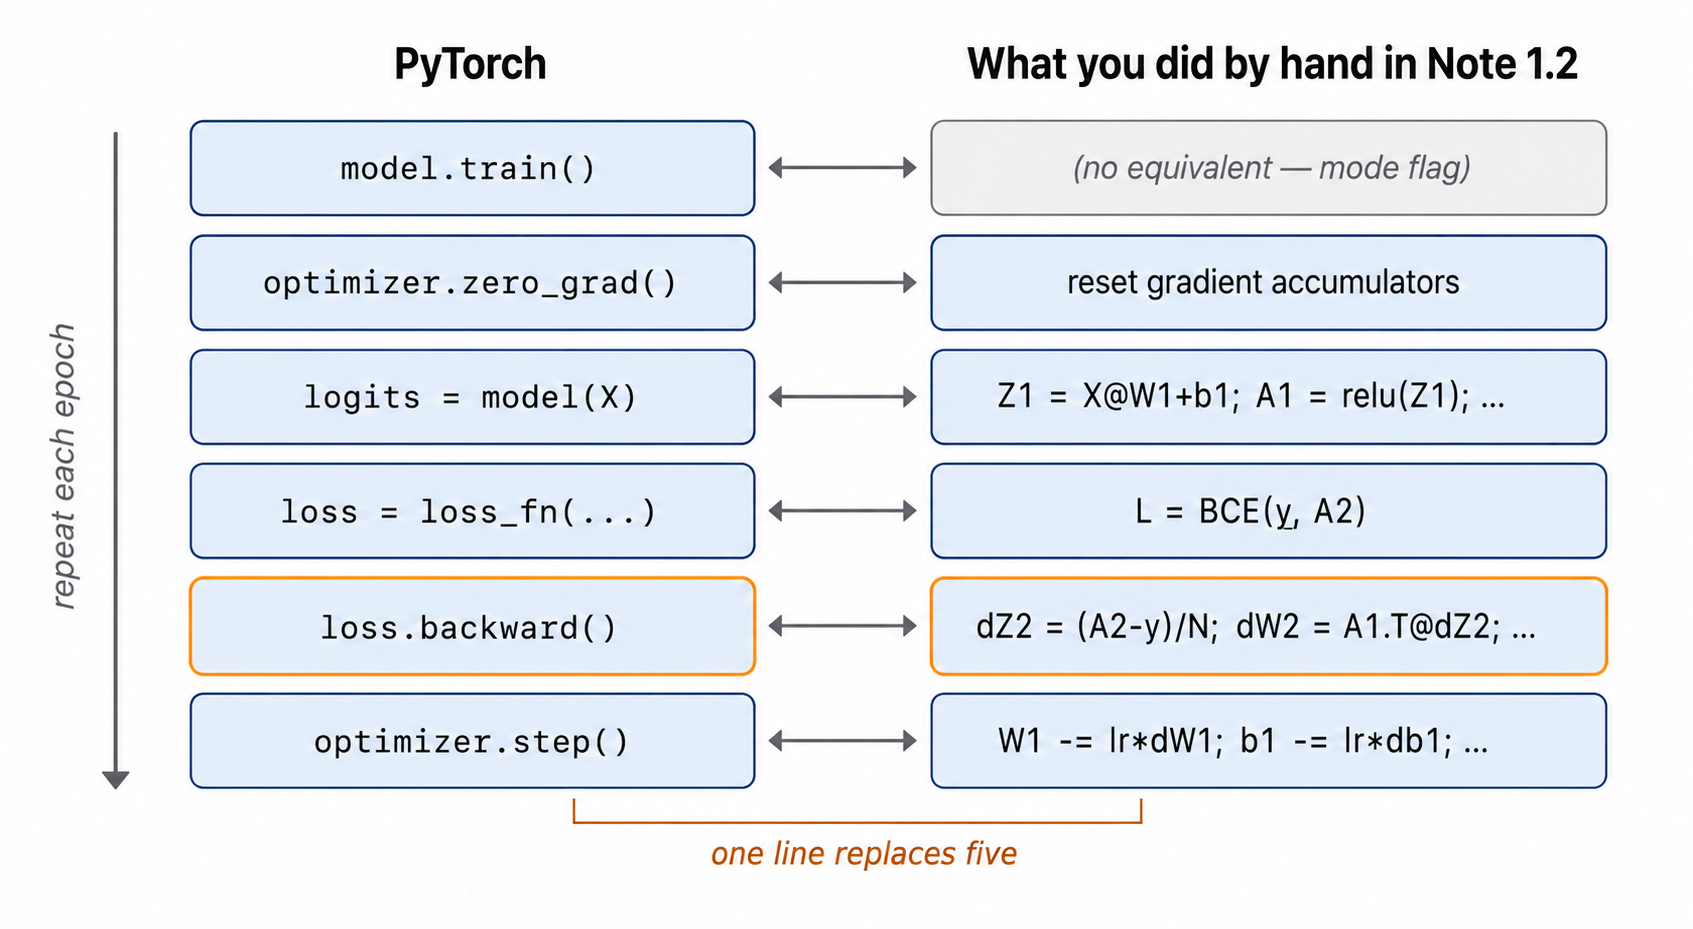


</div>

We add validation. The evaluation block is wrapped in `torch.no_grad()` because we are only measuring, not learning — which skips graph construction and saves both time and memory.

In [46]:
def train_model(model, optimizer, loss_fn, X_tr, y_tr, X_va, y_va, epochs=1500, log_every=50):
    """Full-batch training loop with validation. Returns the loss/accuracy history."""
    history = {"train_loss": [], "val_loss": [], "val_acc": []}

    for epoch in range(epochs):
        # ---------- train ----------
        model.train()
        optimizer.zero_grad()
        logits = model(X_tr)
        loss = loss_fn(logits, y_tr)
        loss.backward()
        optimizer.step()

        # ---------- evaluate ----------
        model.eval()
        with torch.no_grad():
            val_logits = model(X_va)
            val_loss = loss_fn(val_logits, y_va)
            val_acc = ((torch.sigmoid(val_logits) > 0.5).float() == y_va).float().mean()

        history["train_loss"].append(loss.item())
        history["val_loss"].append(val_loss.item())
        history["val_acc"].append(val_acc.item())

        if epoch % log_every == 0 or epoch == epochs - 1:
            print(f"epoch {epoch:>5}   train loss {loss.item():.4f}   "
                  f"val loss {val_loss.item():.4f}   val acc {val_acc.item():.4f}")

    return history

**Questions.**

1. What happens if you put `optimizer.zero_grad()` *after* `loss.backward()` instead of before?
2. Why must `optimizer.step()` come after `loss.backward()` and not before?
3. We evaluate every epoch. On a large dataset, why might that be a poor choice?

## 9. Training on the spirals

Everything is assembled. Point it at the data.

In [57]:
torch.manual_seed(SEED)
model = SpiralNet(hidden=64).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_fn = nn.BCEWithLogitsLoss()

import time
t0 = time.time()
history = train_model(model, optimizer, loss_fn, X_train, y_train, X_val, y_val, epochs=500)
print(f"\ntrained in {time.time() - t0:.1f}s on {DEVICE}")

epoch     0   train loss 0.6990   val loss 0.6778   val acc 0.6200
epoch    50   train loss 0.4954   val loss 0.5086   val acc 0.6840
epoch   100   train loss 0.3089   val loss 0.3571   val acc 0.8120
epoch   150   train loss 0.1965   val loss 0.2494   val acc 0.8640
epoch   200   train loss 0.1214   val loss 0.1700   val acc 0.9320
epoch   250   train loss 0.0869   val loss 0.1324   val acc 0.9640
epoch   300   train loss 0.0659   val loss 0.1129   val acc 0.9680
epoch   350   train loss 0.0528   val loss 0.0989   val acc 0.9720
epoch   400   train loss 0.0432   val loss 0.0933   val acc 0.9720
epoch   450   train loss 0.0375   val loss 0.0917   val acc 0.9760
epoch   499   train loss 0.0313   val loss 0.0868   val acc 0.9760

trained in 0.8s on mps


In [58]:
history.keys()

dict_keys(['train_loss', 'val_loss', 'val_acc'])

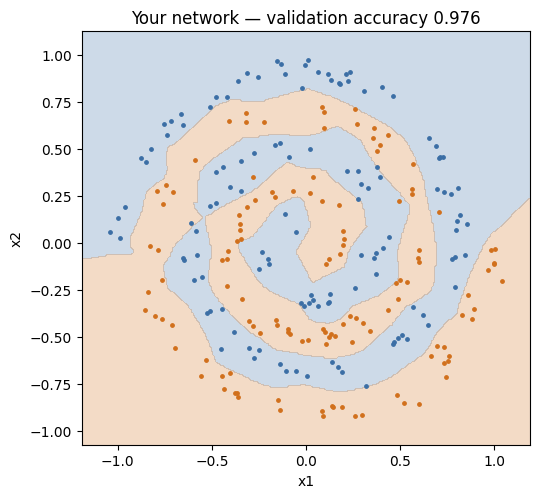

In [59]:
def plot_boundary_torch(model, X_np, y_np, title, ax=None):
    """Shade the decision regions of a torch model over the 2-D input space."""
    if ax is None:
        _, ax = plt.subplots(figsize=(5.5, 5.5))
    pad = 0.15
    g1 = np.linspace(X_np[:, 0].min() - pad, X_np[:, 0].max() + pad, 300)
    g2 = np.linspace(X_np[:, 1].min() - pad, X_np[:, 1].max() + pad, 300)
    G1, G2 = np.meshgrid(g1, g2)
    grid = torch.tensor(np.column_stack([G1.ravel(), G2.ravel()]),
                        dtype=torch.float32, device=DEVICE)
    model.eval()
    with torch.no_grad():
        Z = (torch.sigmoid(model(grid)) > 0.5).float().cpu().numpy().reshape(G1.shape)
    ax.contourf(G1, G2, Z, alpha=0.25, levels=1, colors=["#3b6ea5", "#d1701c"])
    ax.scatter(X_np[y_np == 0, 0], X_np[y_np == 0, 1], s=6, c="#3b6ea5")
    ax.scatter(X_np[y_np == 1, 0], X_np[y_np == 1, 1], s=6, c="#d1701c")
    ax.set_title(title); ax.set_aspect("equal"); ax.set_xlabel("x1"); ax.set_ylabel("x2")
    return ax


plot_boundary_torch(model, X_val_np, y_val_np,
                    f"Your network — validation accuracy {history['val_acc'][-1]:.3f}")
plt.tight_layout(); plt.show()

Compare that with the flat straight seam from Note 1.1, Section 3. Same data, same 1,000 points, same two input features — and a boundary that follows the spiral arms outward.

Nothing was told to this model about radius or angle. It found a usable representation in its hidden layers, exactly as argued in Note 1.1, using the mechanism you traced in Note 1.2, driven by the six lines in Section 8.

**Questions.**

1. Look at the boundary in the outer regions where there is no data. Is the model's confidence there justified?
2. Reduce `hidden` to 4 and retrain. Where does the boundary break down first?
3. How would this picture change with `noise=0.15` in the generator?

## 10. Reading the loss curve

The loss curve is your primary instrument, and Day 3 is largely devoted to reading it. Start building the habit now.

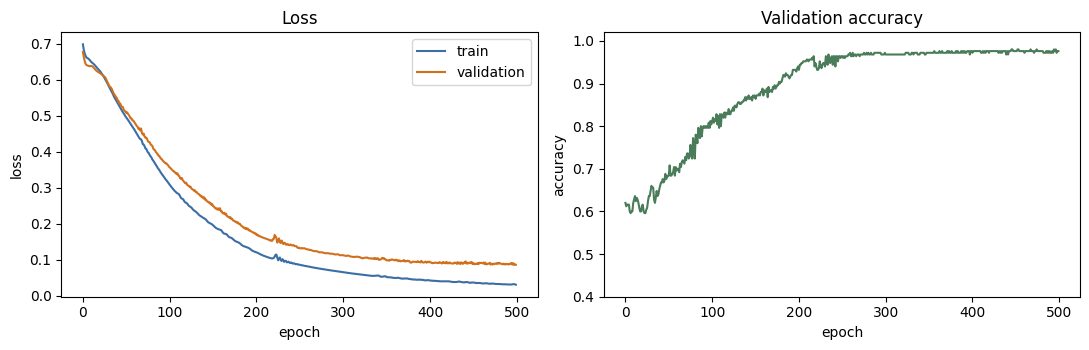

final train loss: 0.0313
final val loss:   0.0868
final val acc:    0.9760
gap (val - train):+0.0555


In [60]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

axes[0].plot(history["train_loss"], label="train", color="#3b6ea5")
axes[0].plot(history["val_loss"], label="validation", color="#d1701c")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss")
axes[0].set_title("Loss"); axes[0].legend()

axes[1].plot(history["val_acc"], color="#4a7c59")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy")
axes[1].set_title("Validation accuracy"); axes[1].set_ylim(0.4, 1.02)

plt.tight_layout(); plt.show()

print(f"final train loss: {history['train_loss'][-1]:.4f}")
print(f"final val loss:   {history['val_loss'][-1]:.4f}")
print(f"final val acc:    {history['val_acc'][-1]:.4f}")
print(f"gap (val - train):{history['val_loss'][-1] - history['train_loss'][-1]:+.4f}")

What to look at, in order:

**Do both curves fall?** Yes — the model is learning something that transfers to unseen data.

**Do they stay close?** Roughly. A small gap is normal and expected. A validation curve that turns *upward* while training loss keeps falling is overfitting, and it is the single most important pattern to recognise.

**Has it flattened?** Largely, which suggests more epochs would add little at this learning rate.

Three shapes to commit to memory now, because you will meet all of them on Day 3:

| Pattern | Diagnosis |
|---|---|
| Both fall, stay close | Healthy |
| Train falls, validation rises | Overfitting |
| Neither falls | Underfitting, bad learning rate, or a bug |

**Questions.**

1. Our validation loss is not rising. With 1,000 points and 4,600 parameters, why might overfitting be milder than you expect?
2. Suppose validation loss bottoms out at epoch 400 then climbs. Which weights would you want to keep? (That is early stopping — Day 3.)
3. Why plot loss and accuracy separately rather than assuming they move together?

## 11. Prediction

A trained model is only useful if you can put new data through it. Three habits make inference correct: evaluation mode, no gradients, and an explicit conversion from logits to probabilities.

In [62]:
def predict(model, X_numpy, threshold=0.5):
    """Run inference on raw NumPy input. Returns (probabilities, predicted labels)."""
    model.eval()                                          # evaluation mode
    x = torch.tensor(X_numpy, dtype=torch.float32, device=DEVICE)
    with torch.no_grad():                                 # no graph, no gradients
        probs = torch.sigmoid(model(x))                   # logits -> probabilities
    probs = probs.cpu().numpy().ravel()                   # back to NumPy for downstream use
    return probs, (probs > threshold).astype(int)

In [63]:
new_points = np.array([[0.0,  0.0],     # dead centre, genuinely ambiguous
                       [0.9,  0.1],     # far out on one arm
                       [-0.9, -0.1],    # far out on the other
                       [0.4,  0.4]])    # somewhere in the middle

new_points

array([[ 0. ,  0. ],
       [ 0.9,  0.1],
       [-0.9, -0.1],
       [ 0.4,  0.4]])

In [64]:
probs, preds = predict(model, new_points)

In [67]:
probs

array([6.3141376e-01, 9.6920478e-05, 9.9248451e-01, 7.9895484e-01],
      dtype=float32)

In [68]:
preds

array([1, 0, 1, 1])

In [69]:
print(f"{'point':<16}{'P(class 1)':>12}{'predicted':>12}")
print("-" * 40)
for pt, p, pr in zip(new_points, probs, preds):
    print(f"{str(pt):<16}{p:>12.4f}{pr:>12d}")

point             P(class 1)   predicted
----------------------------------------
[0. 0.]               0.6314           1
[0.9 0.1]             0.0001           0
[-0.9 -0.1]           0.9925           1
[0.4 0.4]             0.7990           1


Look at the first row against the second and third. Far out on either arm the model is emphatic — probabilities of essentially 0 and 1. At the origin, where both arms begin and the true answer is genuinely ambiguous, it hedges at around 0.64. The confidence tracks the difficulty, which is what you want.

It is only a partial success, though: 0.64 still leans one way on a point that deserves a coin flip. Models are frequently more confident than they have earned, especially away from the training data. Whether a model's stated probability reflects its actual reliability is called **calibration**, and it is a topic Day 9 takes seriously.

**Questions.**

1. Why `model.eval()` when this model has no dropout or batch norm?
2. What would happen if you forgot `torch.no_grad()` during a large inference run?
3. The threshold is 0.5. When would a different threshold be the right engineering choice?

## 12. Saving and loading weights

Save the **state dict** — a dictionary of parameter tensors — not the model object. Saving the object pickles your class definition along with it, which breaks as soon as you refactor. Every serious codebase saves state dicts.

In [74]:
model.state_dict()

OrderedDict([('layer1.weight',
              tensor([[ 0.7171,  0.4779],
                      [-0.8008,  2.0215],
                      [-0.2930, -0.0553],
                      [-0.4128,  2.1209],
                      [ 0.9160, -0.8431],
                      [ 0.8623,  0.0927],
                      [ 1.5785,  0.2075],
                      [ 0.6077, -0.5908],
                      [ 0.5451,  0.1045],
                      [-0.3301,  0.1802],
                      [-1.0012,  0.3609],
                      [-0.4492,  1.1207],
                      [-2.6466,  1.2875],
                      [-0.1997, -0.4252],
                      [-0.0924, -1.1153],
                      [ 1.4064, -1.3284],
                      [ 2.1535,  2.6646],
                      [-0.0054,  1.8055],
                      [ 0.6589,  0.6759],
                      [ 0.2203, -1.1298],
                      [ 0.1972, -0.9236],
                      [ 0.2119,  0.5436],
                      [ 1.3428, -0.8965],
   

In [70]:
from pathlib import Path

Path("checkpoints").mkdir(exist_ok=True)
CKPT = "checkpoints/spiral_net.pt"

# What a state dict actually contains
print("state_dict contents:")
for k, v in model.state_dict().items():
    print(f"  {k:<16} {tuple(v.shape)}")

torch.save(model.state_dict(), CKPT)
print(f"\nsaved to {CKPT}  ({Path(CKPT).stat().st_size / 1024:.1f} KB)")

state_dict contents:
  layer1.weight    (64, 2)
  layer1.bias      (64,)
  layer2.weight    (64, 64)
  layer2.bias      (64,)
  layer3.weight    (1, 64)
  layer3.bias      (1,)

saved to checkpoints/spiral_net.pt  (20.2 KB)


In [71]:
# Reloading: build the architecture first, then pour the weights in
reloaded = SpiralNet(hidden=64).to(DEVICE)
reloaded

SpiralNet(
  (layer1): Linear(in_features=2, out_features=64, bias=True)
  (layer2): Linear(in_features=64, out_features=64, bias=True)
  (layer3): Linear(in_features=64, out_features=1, bias=True)
  (act): ReLU()
)

In [72]:
reloaded.load_state_dict(torch.load(CKPT, map_location=DEVICE))

<All keys matched successfully>

In [73]:
reloaded.eval()

SpiralNet(
  (layer1): Linear(in_features=2, out_features=64, bias=True)
  (layer2): Linear(in_features=64, out_features=64, bias=True)
  (layer3): Linear(in_features=64, out_features=1, bias=True)
  (act): ReLU()
)

In [75]:
p_orig, _ = predict(model, X_val_np)
p_new, _ = predict(reloaded, X_val_np)
print(f"predictions identical: {np.allclose(p_orig, p_new)}")

predictions identical: True


In [87]:
# A fuller checkpoint — what you actually want for resuming an interrupted run
checkpoint = {
    "epoch": 500,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),   # Adam carries state worth preserving
    "val_acc": history["val_acc"][-1],
    "config": {"hidden": 64, "lr": 0.01, "seed": SEED},
}
torch.save(checkpoint, "checkpoints/spiral_full.pt")
print("full checkpoint saved with keys:", list(checkpoint.keys()))

full checkpoint saved with keys: ['epoch', 'model_state_dict', 'optimizer_state_dict', 'val_acc', 'config']


In [88]:
CKPT

'checkpoints/spiral_net.pt'

In [90]:
checkpoint['val_acc']

0.9760000109672546

That `config` entry is a small habit with a large payoff. Three weeks from now, a bare `.pt` file tells you nothing about the learning rate or seed that produced it. Storing the configuration alongside the weights makes a checkpoint self-describing — and it is exactly the reproducibility practice Day 4 formalises.

`map_location=DEVICE` matters too: it lets a checkpoint saved on a Colab GPU load on your Mac, or the reverse. Without it, loading a CUDA checkpoint on a CPU-only machine fails.

**Questions.**

1. Why save the optimizer state? What would resuming without it lose?
2. What must you already know in order to load a state dict successfully?
3. Where in a git repository should model checkpoints live — and should they be committed?

## 13. Deliberate breakage: three changes that stop learning

This is the real test of the day. Each cell below introduces exactly one bug. None of them raises an exception — the code runs, produces numbers, and looks entirely plausible.

That is what makes them dangerous, and learning to recognise their signatures is worth more than any amount of theory.

**Try to predict the symptom before running each cell.**

In [91]:
# ---------- BUG 1: forgetting optimizer.zero_grad() ----------
torch.manual_seed(SEED)
m1 = SpiralNet(hidden=64).to(DEVICE)
opt1 = torch.optim.Adam(m1.parameters(), lr=0.01)
hist1 = []

for epoch in range(600):
    m1.train()
    # opt1.zero_grad()          <-- REMOVED
    loss = loss_fn(m1(X_train), y_train)
    loss.backward()
    opt1.step()
    hist1.append(loss.item())

with torch.no_grad():
    acc1 = ((torch.sigmoid(m1(X_val)) > 0.5).float() == y_val).float().mean().item()
print(f"BUG 1 — no zero_grad()   final loss {hist1[-1]:.4f}   val acc {acc1:.4f}")

BUG 1 — no zero_grad()   final loss 0.8181   val acc 0.5560


In [92]:
# ---------- BUG 2: no activation function (the Note 1.2 Section 4 collapse) ----------
class LinearOnlyNet(nn.Module):
    def __init__(self, hidden=64):
        super().__init__()
        self.layer1 = nn.Linear(2, hidden)
        self.layer2 = nn.Linear(hidden, hidden)
        self.layer3 = nn.Linear(hidden, 1)

    def forward(self, x):
        x = self.layer1(x)      # no ReLU
        x = self.layer2(x)      # no ReLU
        return self.layer3(x)


torch.manual_seed(SEED)
m2 = LinearOnlyNet().to(DEVICE)
opt2 = torch.optim.Adam(m2.parameters(), lr=0.01)
hist2 = []

for epoch in range(600):
    m2.train(); opt2.zero_grad()
    loss = loss_fn(m2(X_train), y_train)
    loss.backward(); opt2.step()
    hist2.append(loss.item())

with torch.no_grad():
    acc2 = ((torch.sigmoid(m2(X_val)) > 0.5).float() == y_val).float().mean().item()
print(f"BUG 2 — no activation    final loss {hist2[-1]:.4f}   val acc {acc2:.4f}")
print(f"         parameters: {sum(p.numel() for p in m2.parameters()):,} — and all of them wasted")

BUG 2 — no activation    final loss 0.6627   val acc 0.6120
         parameters: 4,417 — and all of them wasted


In [93]:
# ---------- BUG 3: learning rate far too high ----------
torch.manual_seed(SEED)
m3 = SpiralNet(hidden=64).to(DEVICE)
opt3 = torch.optim.Adam(m3.parameters(), lr=5.0)      # 500x too large
hist3 = []

for epoch in range(600):
    m3.train(); opt3.zero_grad()
    loss = loss_fn(m3(X_train), y_train)
    loss.backward(); opt3.step()
    hist3.append(loss.item())

with torch.no_grad():
    acc3 = ((torch.sigmoid(m3(X_val)) > 0.5).float() == y_val).float().mean().item()
print(f"BUG 3 — lr = 5.0         final loss {hist3[-1]:.4f}   val acc {acc3:.4f}")

BUG 3 — lr = 5.0         final loss 0.6547   val acc 0.5520


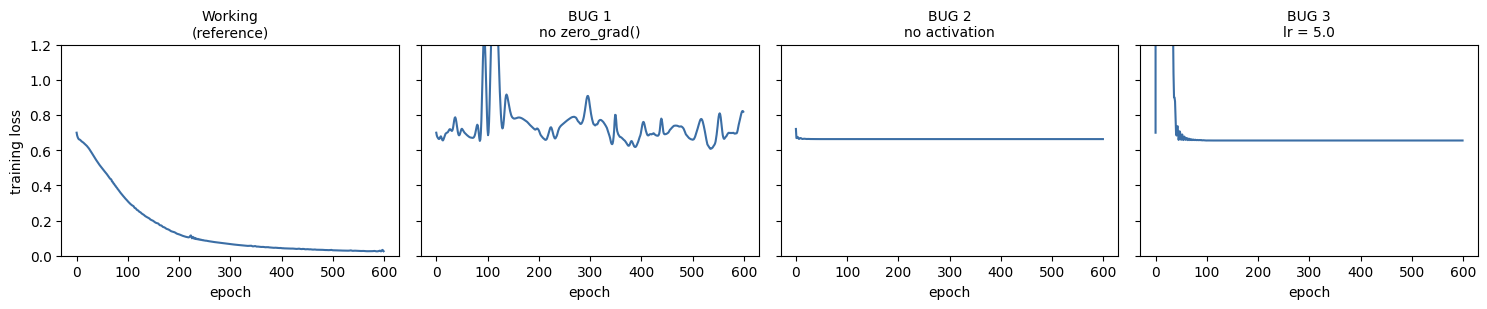

In [94]:
# All three failures against the working model
torch.manual_seed(SEED)
m_ok = SpiralNet(hidden=64).to(DEVICE)
opt_ok = torch.optim.Adam(m_ok.parameters(), lr=0.01)
hist_ok = []
for epoch in range(600):
    m_ok.train(); opt_ok.zero_grad()
    l = loss_fn(m_ok(X_train), y_train)
    l.backward(); opt_ok.step()
    hist_ok.append(l.item())

fig, axes = plt.subplots(1, 4, figsize=(15, 3.2), sharey=True)
for ax, (h, title) in zip(axes, [
        (hist_ok, "Working\n(reference)"),
        (hist1,   "BUG 1\nno zero_grad()"),
        (hist2,   "BUG 2\nno activation"),
        (hist3,   "BUG 3\nlr = 5.0")]):
    ax.plot(h, color="#3b6ea5")
    ax.set_title(title, fontsize=10); ax.set_xlabel("epoch")
axes[0].set_ylabel("training loss"); axes[0].set_ylim(0, 1.2)
plt.tight_layout(); plt.show()

Read the four curves side by side, because the shapes are the diagnostic.

**Bug 1 — no `zero_grad()`.** Gradients accumulate across every epoch, so the effective step keeps growing. The loss is erratic and the model underperforms, but it may not fail outright — which is exactly why this one survives into production code. *Signature: unstable training that no learning-rate change quite fixes.*

**Bug 2 — no activation.** The loss falls smoothly and settles at a respectable-looking value. Everything appears healthy. Now compare the accuracy with Note 1.1, Section 3: logistic regression scored 0.592 on this data, and this 4,417-parameter network scores about 0.61. That is not a coincidence — Note 1.2, Section 4 predicted it exactly. Three stacked linear layers collapse into one, so this is logistic regression in an expensive costume. *Signature: a smooth, healthy-looking curve that plateaus far below what the task should allow.*

**Bug 3 — learning rate 500× too large.** Every step overshoots. The loss spikes, thrashes, and never settles. *Signature: violent oscillation, visible immediately.*

Bug 3 is the easy one — it announces itself. Bugs 1 and 2 are the dangerous ones, because a model that quietly performs at 60% when it should reach 95% will pass code review, ship, and underperform in production without anyone noticing.

This is the professional lesson of Day 1: **your model running without errors tells you nothing about whether it is learning.** Day 3 builds the full diagnostic toolkit.

**Your turn.** Introduce a fourth bug on your own and predict its signature before running it. Some suggestions: pass `y_train` without `unsqueeze(1)` and watch what broadcasting does; swap `BCEWithLogitsLoss` for `BCELoss` on raw logits; set `lr=1e-6`; return `torch.sigmoid(...)` from `forward` while keeping `BCEWithLogitsLoss`.

## 14. End-of-day competency check

Work through these without scrolling back. If any is shaky, revisit that section — Day 2 builds directly on all of it.

**Conceptual**

1. Why did logistic regression fail on the spirals, and why was that not a bug?
2. What is the difference between a learned parameter and an engineered feature?
3. Explain backpropagation in one sentence, using the word "credit".
4. Why does stacking linear layers without activations gain you nothing?
5. Name one situation in 2026 where gradient boosting is the better choice than a neural network.

**Mechanical**

6. Write the six lines of the training loop from memory, in order.
7. What does `optimizer.zero_grad()` do, and what happens without it?
8. Why do we output logits rather than probabilities from `forward`?
9. What are the three properties of a tensor you should always be able to state?
10. A binary classifier starts training at loss 4.2. What does that tell you before you look at anything else?

**Practical**

11. Retrain `SpiralNet` with `hidden=4`. What is the highest validation accuracy you can reach, and what does that tell you about capacity?
12. Take the model to 5,000 epochs. Does validation loss start rising? What would you do about it?
13. Regenerate the spirals with `noise=0.20` and retrain. How does the boundary change, and does the loss curve tell you the data got harder?

## 15. Conclusion

You began Day 1 with a linear model failing at a task you could solve by eye. You end it having built the thing that solves it, from the arithmetic upward.

Along the way, three ideas that the rest of the course rests on:

**Representation learning is the shift.** Not that deep learning is stronger — gradient boosting beat a network on churn in Note 1.1 — but that the transformation from raw input to useful description became something learned rather than written. That matters most where writing it is hopeless.

**The mechanism is not magic.** You computed a forward pass, a loss, a full backward pass and a parameter update by hand, then watched PyTorch reproduce your gradients exactly. `loss.backward()` is now a function whose output you could have produced yourself.

**Running is not learning.** Three bugs, no exceptions raised, plausible-looking output, and a model that had quietly stopped working. Recognising that gap is the beginning of engineering judgement rather than tutorial-following.

The loop you wrote in Section 8 is not a toy. It is the same loop, structurally, that trains the models you will fine-tune on Day 8 and serve on Day 9. What changes between here and there is scale, data handling, and the tooling wrapped around it — never the six lines at the centre.

**One habit to start today.** Open a file called `experiments.md` and record, for every run you make from now on: what you tried, why, what happened, what you learned, what you would change. Four lines. Day 10 asks for this as a deliverable, and the people who start on Day 1 are visibly ahead by Day 5.

## Transition to Day 2

Today's model was handed 750 examples as a single tensor and trained on all of them at once. That works because the spirals are tiny. It stops working almost immediately — a dataset that does not fit in memory cannot be one tensor, and even when it fits, updating once per epoch is a slow way to learn.

Day 2 fixes this properly. You will meet `Dataset` and `DataLoader`, PyTorch's abstractions for feeding data in mini-batches, and the training loop grows an inner loop over batches. You will spend serious time on tensor shapes and shape debugging, because that is where most PyTorch time is genuinely lost. And you will build an MLP for a realistic tabular classification problem, with proper preprocessing.

Day 2 also introduces the engineering practices that carry through the rest of the course: virtual environments, dependency pinning, project structure, and Git. Your work starts becoming a repository rather than a notebook.

**Next:** Day 2 — PyTorch: Building Neural Networks